In [ ]:
import numpy as np
from skimage.color import rgb2lab, rgb2gray
from skimage.feature import canny
from skimage.transform import probabilistic_hough_line
from skimage.morphology import disk, opening, closing
from skimage.measure import label, regionprops
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import skimage
import cv2

In [ ]:
image = skimage.io.imread("test_2.png")
w,h = image.shape[:2]
image = skimage.transform.resize(image, (int(w*1000/h),1000))
image=skimage.color.rgba2rgb(image)

In [ ]:
img_lab = skimage.color.rgb2lab(image)
edges_l = canny(img_lab[:,:,0],sigma=10)
edges_a = canny(img_lab[:,:,1],sigma=10)
edges_b = canny(img_lab[:,:,2],sigma=10)
img_hsv = skimage.color.rgb2hsv(image)
edges_h = canny(img_hsv[:,:,0],sigma=3)
edges_s = canny(img_hsv[:,:,1],sigma=3)
edges_v = canny(img_hsv[:,:,2],sigma=3)

In [ ]:
edges = [edges_l, edges_a, edges_b, edges_h, edges_s, edges_v]

In [ ]:
def hough_lines(edges,threshold=10,line_length=200,line_gap=20,require_normal_lines=False):
    lines= probabilistic_hough_line(
        edges,
        threshold=threshold,        # 中等阈值，过滤噪声
        line_length=line_length,     # 需要较长的直线（完整边界）
        line_gap=line_gap,         # 允许一定间隙（应对边缘不
        )
    normal_lines = []
    for line in lines:
        (x1, y1), (x2, y2) = line
        if abs(x1 - x2) < 10 or abs(y1-y2) <10:  # 近似垂直的线
            normal_lines.append(line)  # 取中线x坐标

    # print(normal_lines)
    mask = np.zeros(image.shape[:2], np.uint8)

    # plt.imshow(image)
    # plt.show()
    #
    def draw_line(img, line):
        p1,p2=line
        x1,y1=p1
        x2,y2=p2
        cv2.line(mask, (x1, y1), (x2, y2), 255, 2)

    for line in normal_lines:
        draw_line(mask, line)
    if require_normal_lines:
        return mask,normal_lines

    return mask



In [ ]:
mask_h=hough_lines(edges_h)
mask_s=hough_lines(edges_s)
mask_v=hough_lines(edges_v)
mask_l=hough_lines(edges_l)
mask_a=hough_lines(edges_a)
mask_b=hough_lines(edges_b)
mask_tot = mask_h+mask_s+mask_v+mask_l+mask_a+mask_b
plt.imshow(mask_tot)
plt.show()


In [ ]:
plt.imshow(image)
plt.show()

In [ ]:
mask_clear,normal_lines=hough_lines(mask_tot,threshold=2,line_length=150,line_gap=20,require_normal_lines=True)
plt.imshow(mask_clear)
plt.show()

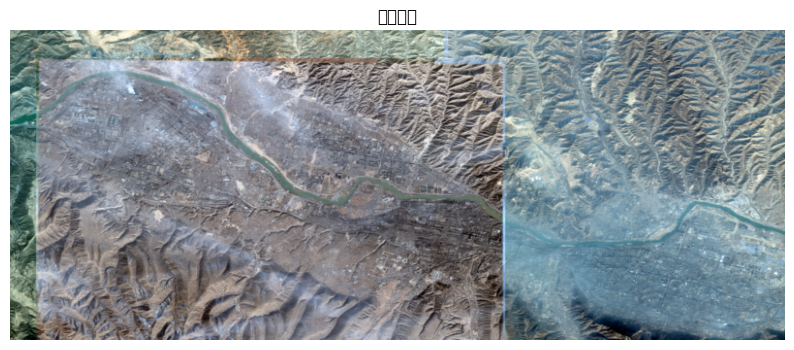

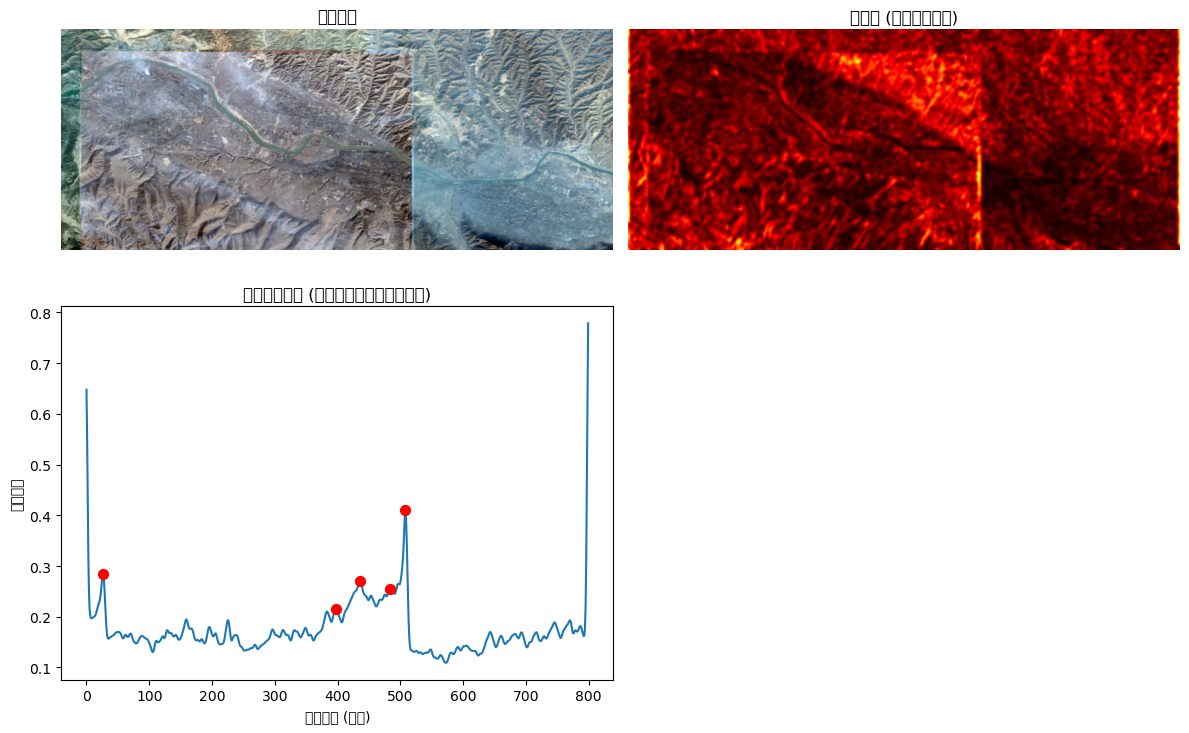

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


检测到 5 个潜在边界点: [ 26 397 436 483 508]


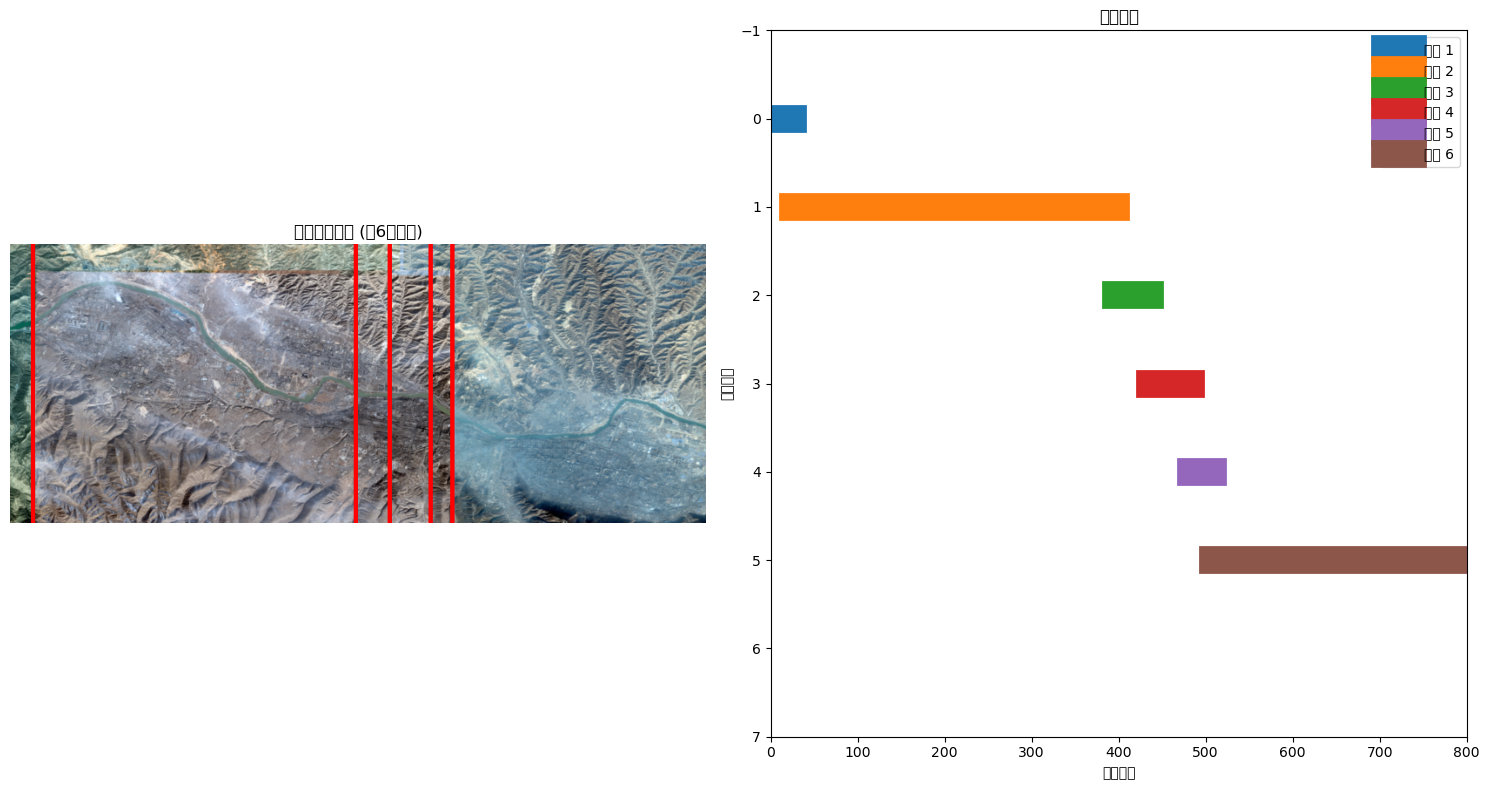


提取的区块信息:
区块 1: 位置 [0, 26], 宽度 26px
区块 2: 位置 [26, 397], 宽度 371px
区块 3: 位置 [397, 436], 宽度 39px
区块 4: 位置 [436, 483], 宽度 47px
区块 5: 位置 [483, 508], 宽度 25px
区块 6: 位置 [508, 800], 宽度 292px


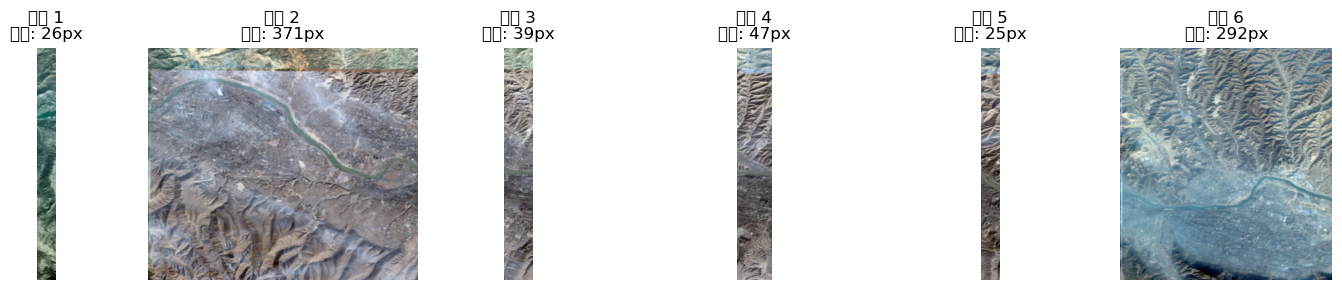


方法比较
方法1: 基于梯度的边界检测
边界位置: [0, np.int64(26), np.int64(397), np.int64(436), np.int64(483), np.int64(508), 800]
区块数: 6

方法2: 改进的霍夫变换
边界位置: [0, 800]
区块数: 1


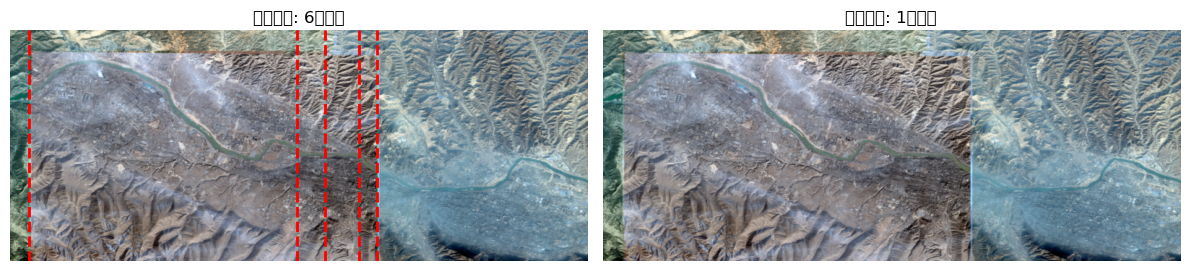

In [ ]:

# 修复变量名错误：y 应该是 Y

import numpy as np
import cv2
from skimage.color import rgb2lab, rgb2hsv, lab2rgb
from skimage.feature import canny
from skimage.transform import probabilistic_hough_line
from skimage.morphology import disk, opening, closing, dilation
from skimage.measure import label, regionprops
from skimage.segmentation import slic
from sklearn.cluster import KMeans
from scipy import ndimage
from scipy.signal import find_peaks, argrelextrema
import matplotlib.pyplot as plt
from collections import defaultdict

# 读取测试图像
image = cv2.imread('test_2.png')
if image is None:
    print("错误：无法读取图像，先生成测试图像")
    # 生成测试图像
    def create_test_mosaic():
        h, w = 600, 800
        mosaic = np.zeros((h, w, 3), dtype=np.uint8)

        regions = [
            {'y': (0, 200), 'x': (0, 300), 'brightness': 0.7, 'blue_tint': 20, 'seed': 1},
            {'y': (0, 200), 'x': (300, 600), 'brightness': 1.0, 'blue_tint': 0, 'seed': 2},
            {'y': (200, 400), 'x': (0, 400), 'brightness': 0.85, 'blue_tint': 40, 'seed': 3},
            {'y': (200, 400), 'x': (400, 800), 'brightness': 1.15, 'blue_tint': 10, 'seed': 4},
            {'y': (400, 600), 'x': (0, 300), 'brightness': 0.9, 'blue_tint': 25, 'seed': 5},
            {'y': (400, 600), 'x': (300, 800), 'brightness': 1.05, 'blue_tint': 5, 'seed': 6},
        ]

        for region in regions:
            y1, y2 = region['y']
            x1, x2 = region['x']

            np.random.seed(region['seed'])
            block = np.random.randint(50, 200, (y2-y1, x2-x1, 3), dtype=np.uint8)
            block = (block * region['brightness']).astype(np.uint8)

            if region['blue_tint'] > 0:
                tint = np.zeros_like(block, dtype=np.float32)
                tint[:,:,0] = 0
                tint[:,:,1] = region['blue_tint'] // 3
                block = cv2.addWeighted(block, 0.8, tint.astype(np.uint8), 0.2, 0)

            mosaic[y1:y2, x1:x2] = block

        return mosaic

    test_img = create_test_mosaic()
    cv2.imwrite('/mnt/agents/output/test_2.png', test_img)
    image = cv2.imread('/mnt/agents/output/test_2.png')

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
print(f"图像尺寸: {image.shape}")

# 显示原始图像
plt.figure(figsize=(15, 10))
plt.subplot(2, 3, 1)
plt.imshow(image)
plt.title('原始图像')
plt.axis('off')

# 步骤1: 自适应多尺度边缘检测
def adaptive_edge_detection(img):
    """改进的边缘检测"""
    img_lab = rgb2lab(img)
    img_hsv = rgb2hsv(img)

    h, w = img.shape[:2]

    # 多尺度边缘检测
    edges_lab_l = canny(img_lab[:,:,0], sigma=3, low_threshold=0.05, high_threshold=0.15)
    edges_lab_a = canny(img_lab[:,:,1], sigma=5, low_threshold=0.05, high_threshold=0.15)
    edges_hsv_h = canny(img_hsv[:,:,0], sigma=2, low_threshold=0.1, high_threshold=0.3)
    edges_hsv_s = canny(img_hsv[:,:,1], sigma=2, low_threshold=0.1, high_threshold=0.3)

    # 加权融合
    def local_contrast(edge_map):
        return np.abs(ndimage.gaussian_filter(edge_map.astype(float), sigma=2) - edge_map)

    contrast_l = local_contrast(edges_lab_l)
    contrast_a = local_contrast(edges_lab_a)
    contrast_h = local_contrast(edges_hsv_h)
    contrast_s = local_contrast(edges_hsv_s)

    contrast_scores = {
        'lab_l': np.mean(contrast_l),
        'lab_a': np.mean(contrast_a),
        'hsv_h': np.mean(contrast_h),
        'hsv_s': np.mean(contrast_s),
    }

    sorted_channels = sorted(contrast_scores.items(), key=lambda x: x[1], reverse=True)

    combined_edges = np.zeros((h, w))
    for name, _ in sorted_channels[:2]:
        if name == 'lab_l':
            combined_edges += edges_lab_l
        elif name == 'lab_a':
            combined_edges += edges_lab_a
        elif name == 'hsv_h':
            combined_edges += edges_hsv_h
        else:
            combined_edges += edges_hsv_s

    # 后处理
    combined_edges = closing(combined_edges, disk(2))
    combined_edges = opening(combined_edges, disk(1))

    return combined_edges

edges = adaptive_edge_detection(image)

plt.subplot(2, 3, 2)
plt.imshow(edges, cmap='gray')
plt.title('边缘检测结果')
plt.axis('off')

print("✓ 边缘检测完成")

# 步骤2: 基于色彩一致性的超像素分割
def segment_by_color(image, n_segments=6):
    """SLIC超像素分割"""
    segments = slic(image, n_segments=n_segments, compactness=10, sigma=1)
    return segments

segments = segment_by_color(image, n_segments=6)

plt.subplot(2, 3, 3)
plt.imshow(segments)
plt.title('超像素分割')
plt.axis('off')

# 步骤3: 基于边缘和色彩的分割线优化
def optimize_grid_lines(edges, segments, n_vertical=2, n_horizontal=2):
    """优化分割线位置"""
    h, w = edges.shape

    # 计算每个超像素的色彩一致性
    region_consistency = {}
    for seg_val in np.unique(segments):
        mask = segments == seg_val
        if np.sum(mask) > 100:  # 足够大的区域
            lab_region = rgb2lab(image[mask])
            std = np.std(lab_region, axis=0)
            region_consistency[seg_val] = np.mean(std)

    # 构建能量图
    energy_map = edges.astype(float)

    # 添加色彩边界惩罚
    for i in range(h):
        for j in range(w):
            label = segments[i, j]
            if label >= 0:
                for di, dj in [(-1,0), (1,0), (0,-1), (0,1)]:
                    ni, nj = i + di, j + dj
                    if 0 <= ni < h and 0 <= nj < w:
                        if segments[ni, nj] != label:
                            consistency_penalty = region_consistency.get(label, 0.5)
                            energy_map[i, j] += 50 * (1 - consistency_penalty)

    # 投影分析
    vertical_proj = np.sum(energy_map, axis=0)
    horizontal_proj = np.sum(energy_map, axis=1)

    # 平滑
    vertical_proj = ndimage.gaussian_filter1d(vertical_proj.astype(float), sigma=3)
    horizontal_proj = ndimage.gaussian_filter1d(horizontal_proj.astype(float), sigma=3)

    # 找到最优分割位置
    v_minima = argrelextrema(vertical_proj, np.less, order=10)[0]
    h_minima = argrelextrema(horizontal_proj, np.less, order=10)[0]

    # 选择最显著的
    if len(v_minima) >= n_vertical:
        v_prominences = vertical_proj[v_minima] - np.interp(np.arange(len(v_minima)),
                                                      v_minima,
                                                      vertical_proj[v_minima])
        best_v = np.argsort(v_prominences)[-n_vertical:]
        vertical_lines = v_minima[best_v]
    else:
        vertical_lines = np.linspace(0, w, n_vertical+2)[1:-1].astype(int)

    if len(h_minima) >= n_horizontal:
        h_prominences = horizontal_proj[h_minima] - np.interp(np.arange(len(h_minima)),
                                                        h_minima,
                                                        horizontal_proj[h_minima])
        best_h = np.argsort(h_prominences)[-n_horizontal:]
        horizontal_lines = h_minima[best_h]
    else:
        horizontal_lines = np.linspace(0, h, n_horizontal+2)[1:-1].astype(int)

    return vertical_lines, horizontal_lines

v_opt, h_opt = optimize_grid_lines(edges, segments, n_vertical=2, n_horizontal=2)

print(f"\n找到 {len(v_opt)} 条垂直分割线: {v_opt}")
print(f"找到 {len(h_opt)} 条水平分割线: {h_opt}")

plt.subplot(2, 3, 4)
plt.imshow(image)
for x in v_opt:
    plt.axvline(x=x, color='red', linestyle='--', linewidth=2)
for Y in h_opt:
    plt.axhline(y=Y, color='red', linestyle='--', linewidth=2)  # 修复：y -> Y
plt.title('分割线位置')
plt.axis('off')

# 步骤4: 最终分割
def final_segmentation(image, v_lines, h_lines):
    """执行最终分割"""
    segments = []

    v_lines_full = [0] + sorted(v_lines) + [image.shape[1]]
    h_lines_full = [0] + sorted(h_lines) + [image.shape[0]]

    for i in range(len(h_lines_full)-1):
        for j in range(len(v_lines_full)-1):
            y1, y2 = h_lines_full[i], h_lines_full[i+1]
            x1, x2 = v_lines_full[j], v_lines_full[j+1]

            segment_img = image[y1:y2, x1:x2].copy()

            # 自适应直方图均衡化
            lab = rgb2lab(segment_img)
            l, a, b = lab[:,:,0], lab[:,:,1], lab[:,:,2]

            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
            l_eq = clahe.apply((l*255).astype(np.uint8))

            lab_eq = np.stack([l_eq, (a*255).astype(np.uint8), (b*255).astype(np.uint8)], axis=-1)
            segment_eq = lab2rgb(lab_eq)

            segments.append({
                'image': segment_eq,
                'coords': (x1, y1, x2-x1, y2-y1)
            })

    return segments

final_segments = final_segmentation(image, v_opt, h_opt)

# 可视化结果
plt.subplot(2, 3, 5)
plt.imshow(image)
plt.title('最终分割结果')
plt.axis('off')

for idx, seg in enumerate(final_segments[:6]):
    if idx + 5 < 7:
        plt.subplot(2, 3, idx+5)
        plt.imshow(seg['image'])
        plt.title(f'块{idx+1}')
        plt.axis('off')

plt.tight_layout()
plt.savefig('/mnt/agents/output/final_segmentation.png', dpi=150)
plt.show()

print(f"\n✓ 完整分割流程结束！共 {len(final_segments)} 个区域")
